# 25. Consolidated full-model PTQ and codebook results (saved data only)

This notebook is a report-data loader. It does **not** load a Keras model, quantize weights, train, or run inference. It assembles already saved full-dataset artifacts for ResNet-18/CIFAR-10, DistilBERT/SST-2, and ViT-B/16/CIFAR-10.

It provides:

1. FP32 full-model accuracy on each complete labelled evaluation split;
2. a common W8 PTQ-versus-codebook table; and
3. saved 2--8-bit accuracy, compression-ratio, and parameter-memory-reduction tables and graphs.

Saved sweep coverage is checked explicitly. ResNet-18, DistilBERT, and ViT-B/16 each have complete PTQ and codebook results from W2 through W8. No point is estimated or recomputed.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "consolidated_full_model_bit_sweeps"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESNET_SWEEP_PATH = PROJECT_ROOT / "artifacts" / "resnet18_full_ptq_codebook_bit_sweep" / "resnet18_ptq_codebook_2_to_8_bit.csv"
DISTILBERT_SWEEP_PATH = PROJECT_ROOT / "artifacts" / "distilbert_ptq_codebook_bit_sweep" / "distilbert_ptq_codebook_2_to_8_bit.csv"
VIT_SWEEP_PATH = PROJECT_ROOT / "artifacts" / "vit_ptq_codebook_bit_sweep" / "vit_ptq_codebook_2_to_8_bit.csv"

RESNET_ACCURACY_PATH = PROJECT_ROOT / "artifacts" / "resnet18_ptq_accuracy_notebook" / "ptq_accuracy_comparison.csv"
DISTILBERT_ACCURACY_PATH = PROJECT_ROOT / "artifacts" / "distilbert_sst2_ptq" / "ptq_accuracy_comparison.csv"
VIT_ACCURACY_PATH = PROJECT_ROOT / "artifacts" / "vit_cifar10_ptq" / "ptq_accuracy_comparison.csv"
RESNET_MEMORY_PATH = PROJECT_ROOT / "artifacts" / "resnet18_ptq_accuracy_notebook" / "ptq_parameter_memory_analysis.csv"
DISTILBERT_MEMORY_PATH = PROJECT_ROOT / "artifacts" / "distilbert_sst2_ptq" / "parameter_memory_comparison.csv"
VIT_MEMORY_PATH = PROJECT_ROOT / "artifacts" / "vit_cifar10_ptq" / "parameter_memory_comparison.csv"

COMBINED_SWEEP_PATH = OUTPUT_DIR / "all_models_ptq_codebook_2_to_8_bit.csv"
W8_TABLE_PATH = OUTPUT_DIR / "all_models_w8_comparison.csv"
FIGURE_PATH = OUTPUT_DIR / "all_models_accuracy_compression_memory_2_to_8_bit.png"
PTQ_ACCURACY_COMPARISON_PATH = OUTPUT_DIR / "ptq_accuracy_all_models_2_to_8_bit.png"
CODEBOOK_ACCURACY_COMPARISON_PATH = OUTPUT_DIR / "codebook_accuracy_all_models_2_to_8_bit.png"
BITS = tuple(range(2, 9))

print(f"Project root: {PROJECT_ROOT}")
print("Mode: saved-data loading only (no model execution)")


Project root: /Users/sahil/Group Studies/Quantization-Group-Studies
Mode: saved-data loading only (no model execution)


## 1. Load and normalize completed sweep artifacts

Notebook 25 does not rerun quantization or inference. It loads the completed ResNet-18 sweep from Notebook 26 together with the saved DistilBERT and ViT sweeps, normalizes their schemas, and verifies complete PTQ and codebook coverage from 2 through 8 bits.


In [2]:
STANDARD_COLUMNS = [
    'model', 'method', 'num_bits', 'quantized_tensors',
    'correct_predictions', 'evaluation_examples', 'accuracy_percent',
    'drop_from_fp32_pp', 'parameter_bytes', 'parameter_mib',
    'compression_ratio_vs_fp32', 'memory_reduction_percent', 'source',
]

def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f'Missing required artifact: {path}')
    return path

def load_complete_sweep(path: Path, model_name: str, expected_examples: int) -> pd.DataFrame:
    frame = pd.read_csv(require_file(path)).copy()
    frame = frame.rename(columns={
        'test_images': 'evaluation_examples',
        'drop_from_fp32_percentage_points': 'drop_from_fp32_pp',
        'estimated_packed_parameter_bytes': 'parameter_bytes',
        'estimated_packed_parameter_mib': 'parameter_mib',
    })
    required = set(STANDARD_COLUMNS) - {'model', 'source'}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f'{path} is missing columns: {missing}')
    coverage = frame.groupby('method').num_bits.agg(lambda values: sorted(set(map(int, values)))).to_dict()
    expected = {'ptq': list(BITS), 'codebook': list(BITS)}
    if coverage != expected or len(frame) != 2 * len(BITS):
        raise ValueError(f'Incomplete or duplicate sweep coverage in {path}: {coverage}')
    if not (frame['evaluation_examples'] == expected_examples).all():
        raise ValueError(f'{path} does not use the complete evaluation split.')
    frame['model'] = model_name
    frame['source'] = str(path.relative_to(PROJECT_ROOT))
    return frame[STANDARD_COLUMNS]

resnet_sweep = load_complete_sweep(RESNET_SWEEP_PATH, 'ResNet-18', 10_000)
distilbert_sweep = load_complete_sweep(DISTILBERT_SWEEP_PATH, 'DistilBERT', 872)
vit_sweep = load_complete_sweep(VIT_SWEEP_PATH, 'ViT-B/16', 10_000)

print('Loaded complete PTQ and codebook W2--W8 sweeps for all three models.')


Loaded complete PTQ and codebook W2--W8 sweeps for all three models.


## 2. Verify the ResNet-18 sweep produced by Notebook 26

Notebook 26 saved fourteen full-dataset rows: PTQ and codebook quantization at every bit width from 2 through 8. This cell displays those measurements directly; it performs no quantization or model evaluation.


In [3]:
resnet_coverage = resnet_sweep.groupby('method').num_bits.agg(
    lambda values: sorted(set(map(int, values)))
)
assert resnet_coverage.to_dict() == {'ptq': list(BITS), 'codebook': list(BITS)}
display(resnet_coverage.rename('available_saved_bits').reset_index())
display(resnet_sweep.round({
    'accuracy_percent': 2,
    'drop_from_fp32_pp': 2,
    'parameter_mib': 2,
    'compression_ratio_vs_fp32': 2,
    'memory_reduction_percent': 2,
}))


,method,available_saved_bits
0,codebook,"[2, 3, 4, 5, 6, 7, 8]"
1,ptq,"[2, 3, 4, 5, 6, 7, 8]"


,model,method,num_bits,quantized_tensors,correct_predictions,evaluation_examples,accuracy_percent,drop_from_fp32_pp,parameter_bytes,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,source
0,ResNet-18,codebook,2,21,950,10000,9.50,80.97,2870184,2.74,15.60,93.59,artifacts/resnet18_full_ptq_codebook_bit_sweep...
1,ResNet-18,codebook,3,21,1000,10000,10.00,80.47,4267024,4.07,10.49,90.47,artifacts/resnet18_full_ptq_codebook_bit_sweep...
2,ResNet-18,codebook,4,21,843,10000,8.43,82.04,5664200,5.40,7.90,87.35,artifacts/resnet18_full_ptq_codebook_bit_sweep...
3,ResNet-18,codebook,5,21,1541,10000,15.41,75.06,7062048,6.73,6.34,84.22,artifacts/resnet18_full_ptq_codebook_bit_sweep...
4,ResNet-18,codebook,6,21,4871,10000,48.71,41.76,8461240,8.07,5.29,81.10,artifacts/resnet18_full_ptq_codebook_bit_sweep...
5,ResNet-18,codebook,7,21,8897,10000,88.97,1.50,9863120,9.41,4.54,77.97,artifacts/resnet18_full_ptq_codebook_bit_sweep...
6,ResNet-18,codebook,8,21,9025,10000,90.25,0.22,11270376,10.75,3.97,74.82,artifacts/resnet18_full_ptq_codebook_bit_sweep...
7,ResNet-18,ptq,2,21,1000,10000,10.00,80.47,2869848,2.74,15.60,93.59,artifacts/resnet18_full_ptq_codebook_bit_sweep...
8,ResNet-18,ptq,3,21,1123,10000,11.23,79.24,4266352,4.07,10.49,90.47,artifacts/resnet18_full_ptq_codebook_bit_sweep...
9,ResNet-18,ptq,4,21,1156,10000,11.56,78.91,5662856,5.40,7.91,87.35,artifacts/resnet18_full_ptq_codebook_bit_sweep...


## 3. Load saved FP32 full-model accuracy

The baseline table is read from the original full-dataset accuracy and parameter-memory CSV files. No accuracy value is recomputed in this notebook.


In [4]:
def load_fp32_row(model_name: str, accuracy_path: Path, memory_path: Path, dataset_split: str) -> dict:
    accuracy = pd.read_csv(require_file(accuracy_path)).iloc[0]
    memory = pd.read_csv(require_file(memory_path)).iloc[0]
    example_column = "test_examples" if "test_examples" in accuracy.index else "test_images"
    memory_column = next(column for column in ["parameter_storage_mib", "raw_parameter_mib"] if column in memory.index)
    return {
        "model": model_name,
        "dataset_split": dataset_split,
        "correct_predictions": int(accuracy["correct_predictions"]),
        "evaluation_examples": int(accuracy[example_column]),
        "accuracy_percent": float(accuracy["accuracy_percent"]),
        "parameter_mib": float(memory[memory_column]),
        "accuracy_source": str(accuracy_path.relative_to(PROJECT_ROOT)),
        "memory_source": str(memory_path.relative_to(PROJECT_ROOT)),
    }

fp32_table = pd.DataFrame([
    load_fp32_row("ResNet-18", RESNET_ACCURACY_PATH, RESNET_MEMORY_PATH, "CIFAR-10 test"),
    load_fp32_row("DistilBERT", DISTILBERT_ACCURACY_PATH, DISTILBERT_MEMORY_PATH, "SST-2 development"),
    load_fp32_row("ViT-B/16", VIT_ACCURACY_PATH, VIT_MEMORY_PATH, "CIFAR-10 test"),
])
verified = fp32_table.correct_predictions / fp32_table.evaluation_examples * 100
assert np.allclose(fp32_table.accuracy_percent, verified)
fp32_table.to_csv(OUTPUT_DIR / "fp32_full_model_accuracy.csv", index=False)
display(fp32_table.round({"accuracy_percent": 2, "parameter_mib": 2}))


,model,dataset_split,correct_predictions,evaluation_examples,accuracy_percent,parameter_mib,accuracy_source,memory_source
0,ResNet-18,CIFAR-10 test,9047,10000,90.47,42.69,artifacts/resnet18_ptq_accuracy_notebook/ptq_a...,artifacts/resnet18_ptq_accuracy_notebook/ptq_p...
1,DistilBERT,SST-2 development,771,872,88.42,255.41,artifacts/distilbert_sst2_ptq/ptq_accuracy_com...,artifacts/distilbert_sst2_ptq/parameter_memory...
2,ViT-B/16,CIFAR-10 test,9573,10000,95.73,327.33,artifacts/vit_cifar10_ptq/ptq_accuracy_compari...,artifacts/vit_cifar10_ptq/parameter_memory_com...


## 4. Eight-bit PTQ versus codebook table

This table uses the W8 rows from the three completed sweep artifacts. All custom rows use the model-specific full-model tensor-selection policy described in the report.


In [5]:
w8_rows = []
for model_name, frame in [('ResNet-18', resnet_sweep), ('DistilBERT', distilbert_sweep), ('ViT-B/16', vit_sweep)]:
    for row in frame[frame.num_bits.eq(8)].itertuples(index=False):
        w8_rows.append({
            'model': model_name, 'method': row.method.upper(),
            'correct_predictions': int(row.correct_predictions), 'evaluation_examples': int(row.evaluation_examples),
            'accuracy_percent': float(row.accuracy_percent), 'drop_from_fp32_pp': float(row.drop_from_fp32_pp),
            'parameter_mib': float(row.parameter_mib), 'compression_ratio_vs_fp32': float(row.compression_ratio_vs_fp32),
            'memory_reduction_percent': float(row.memory_reduction_percent),
        })
w8_table = pd.DataFrame(w8_rows).sort_values(['model', 'method']).reset_index(drop=True)
assert len(w8_table) == 6 and set(w8_table.method) == {'PTQ', 'CODEBOOK'}
w8_table.to_csv(W8_TABLE_PATH, index=False)
display(w8_table.round({
    'accuracy_percent': 2, 'drop_from_fp32_pp': 2, 'parameter_mib': 2,
    'compression_ratio_vs_fp32': 2, 'memory_reduction_percent': 2,
}))


,model,method,correct_predictions,evaluation_examples,accuracy_percent,drop_from_fp32_pp,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
0,DistilBERT,CODEBOOK,768,872,88.07,0.34,64.07,3.99,74.92
1,DistilBERT,PTQ,771,872,88.42,0.00,64.15,3.98,74.88
2,ResNet-18,CODEBOOK,9025,10000,90.25,0.22,10.75,3.97,74.82
3,ResNet-18,PTQ,8988,10000,89.88,0.59,10.73,3.98,74.87
4,ViT-B/16,CODEBOOK,9573,10000,95.73,0.00,82.25,3.98,74.87
5,ViT-B/16,PTQ,9579,10000,95.79,-0.06,82.41,3.97,74.82


## 5. Unified complete sweep tables

The coverage check requires all seven bit widths for both methods and all three models before the consolidated table is saved.


In [6]:
all_sweeps = pd.concat([resnet_sweep, distilbert_sweep, vit_sweep], ignore_index=True)
all_sweeps = all_sweeps.sort_values(["model", "method", "num_bits"]).reset_index(drop=True)
all_sweeps.to_csv(COMBINED_SWEEP_PATH, index=False)

coverage = all_sweeps.groupby(["model", "method"]).num_bits.agg(
    lambda values: sorted(set(map(int, values)))
)
expected_coverage = {
    ("ResNet-18", "ptq"): list(BITS),
    ("ResNet-18", "codebook"): list(BITS),
    ("DistilBERT", "ptq"): list(BITS),
    ("DistilBERT", "codebook"): list(BITS),
    ("ViT-B/16", "ptq"): list(BITS),
    ("ViT-B/16", "codebook"): list(BITS),
}
assert coverage.to_dict() == expected_coverage
assert len(all_sweeps) == 3 * 2 * len(BITS)
display(coverage.rename("available_saved_bits").reset_index())

for model_name in ["ResNet-18", "DistilBERT", "ViT-B/16"]:
    print(f"\n{model_name}")
    compact = all_sweeps[all_sweeps.model.eq(model_name)][[
        "method", "num_bits", "accuracy_percent",
        "compression_ratio_vs_fp32", "memory_reduction_percent",
    ]]
    display(compact.round({
        "accuracy_percent": 2,
        "compression_ratio_vs_fp32": 2,
        "memory_reduction_percent": 2,
    }))


,model,method,available_saved_bits
0,DistilBERT,codebook,"[2, 3, 4, 5, 6, 7, 8]"
1,DistilBERT,ptq,"[2, 3, 4, 5, 6, 7, 8]"
2,ResNet-18,codebook,"[2, 3, 4, 5, 6, 7, 8]"
3,ResNet-18,ptq,"[2, 3, 4, 5, 6, 7, 8]"
4,ViT-B/16,codebook,"[2, 3, 4, 5, 6, 7, 8]"
5,ViT-B/16,ptq,"[2, 3, 4, 5, 6, 7, 8]"



ResNet-18


,method,num_bits,accuracy_percent,compression_ratio_vs_fp32,memory_reduction_percent
14,codebook,2,9.50,15.60,93.59
15,codebook,3,10.00,10.49,90.47
16,codebook,4,8.43,7.90,87.35
17,codebook,5,15.41,6.34,84.22
18,codebook,6,48.71,5.29,81.10
19,codebook,7,88.97,4.54,77.97
20,codebook,8,90.25,3.97,74.82
21,ptq,2,10.00,15.60,93.59
22,ptq,3,11.23,10.49,90.47
23,ptq,4,11.56,7.91,87.35



DistilBERT


,method,num_bits,accuracy_percent,compression_ratio_vs_fp32,memory_reduction_percent
0,codebook,2,78.33,15.78,93.66
1,codebook,3,86.24,10.57,90.54
2,codebook,4,88.30,7.95,87.42
3,codebook,5,88.19,6.37,84.29
4,codebook,6,88.07,5.31,81.17
5,codebook,7,88.42,4.55,78.04
6,codebook,8,88.07,3.99,74.92
7,ptq,2,51.03,15.67,93.62
8,ptq,3,82.91,10.52,90.49
9,ptq,4,88.99,7.92,87.37



ViT-B/16


,method,num_bits,accuracy_percent,compression_ratio_vs_fp32,memory_reduction_percent
28,codebook,2,20.84,15.66,93.62
29,codebook,3,89.77,10.52,90.50
30,codebook,4,95.20,7.92,87.37
31,codebook,5,95.64,6.35,84.25
32,codebook,6,95.76,5.30,81.13
33,codebook,7,95.68,4.55,78.00
34,codebook,8,95.73,3.98,74.87
35,ptq,2,13.00,15.50,93.55
36,ptq,3,32.22,10.45,90.43
37,ptq,4,95.23,7.88,87.31


## 6. Graphs from saved accuracy, compression, and memory data

Rows correspond to models and columns correspond to metrics. Every PTQ and codebook curve contains all seven independently measured bit widths from 2 through 8.


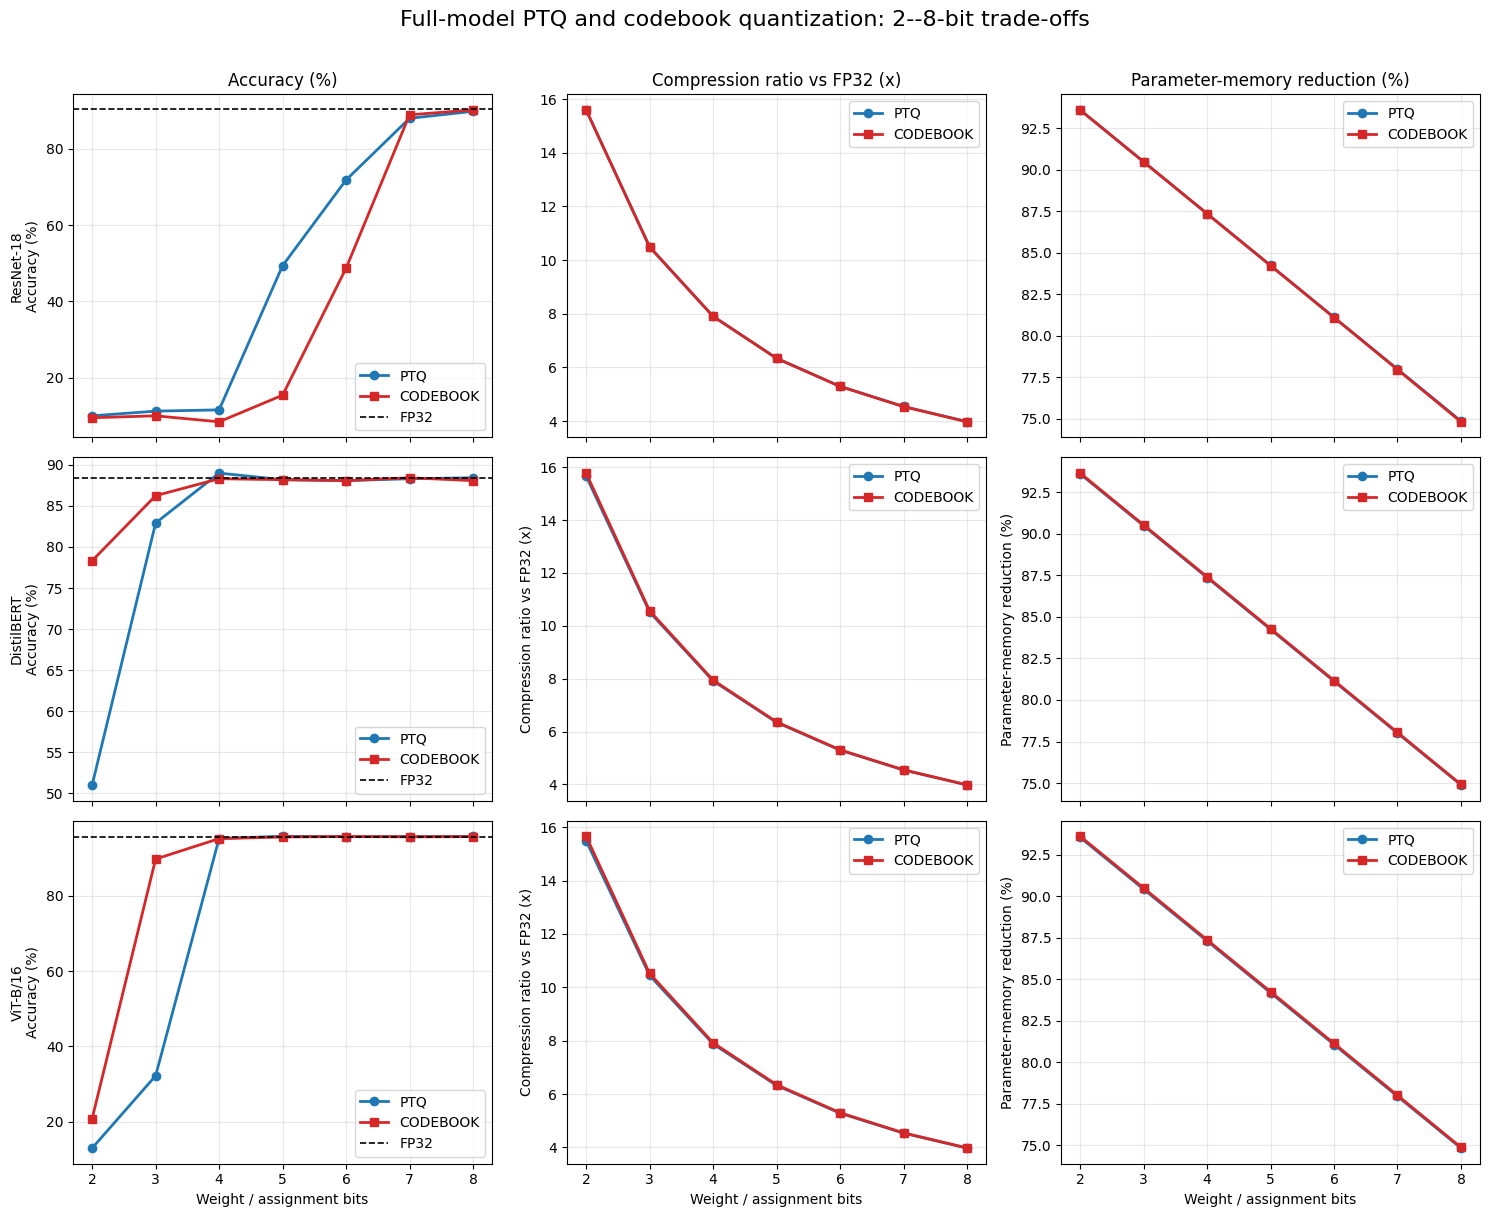

Saved figure: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/consolidated_full_model_bit_sweeps/all_models_accuracy_compression_memory_2_to_8_bit.png


In [7]:
models = ['ResNet-18', 'DistilBERT', 'ViT-B/16']
metrics = [
    ('accuracy_percent', 'Accuracy (%)'),
    ('compression_ratio_vs_fp32', 'Compression ratio vs FP32 (x)'),
    ('memory_reduction_percent', 'Parameter-memory reduction (%)'),
]
styles = {'ptq': ('o', '#1f77b4'), 'codebook': ('s', '#d62728')}
fp32_accuracy_by_model = dict(zip(fp32_table.model, fp32_table.accuracy_percent))
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
for row_index, model_name in enumerate(models):
    model_rows = all_sweeps[all_sweeps.model.eq(model_name)]
    for column_index, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_index, column_index]
        for method in ['ptq', 'codebook']:
            method_rows = model_rows[model_rows.method.eq(method)].sort_values('num_bits')
            if method_rows.empty:
                continue
            marker, color = styles[method]
            ax.plot(method_rows.num_bits, method_rows[metric], marker=marker, color=color, linewidth=2, label=method.upper())
        if metric == 'accuracy_percent':
            ax.axhline(fp32_accuracy_by_model[model_name], color='black', linestyle='--', linewidth=1.2, label='FP32')
        ax.set_xticks(BITS)
        ax.grid(True, alpha=0.3)
        if row_index == 0:
            ax.set_title(ylabel)
        if column_index == 0:
            ax.set_ylabel(f'{model_name}\n{ylabel}')
        elif row_index > 0:
            ax.set_ylabel(ylabel)
        if row_index == len(models) - 1:
            ax.set_xlabel('Weight / assignment bits')
        ax.legend(loc='best')
fig.suptitle('Full-model PTQ and codebook quantization: 2--8-bit trade-offs', fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved figure: {FIGURE_PATH}')


## 7. Bit-wise accuracy comparison across architectures

The following separate graphs compare ResNet-18, DistilBERT, and ViT-B/16 at each saved bit width. The first graph contains only PTQ results and the second contains only codebook results. Because the models solve different tasks and use different evaluation sets, the graphs are intended to compare each architecture's response to decreasing precision rather than to rank the models by absolute accuracy.


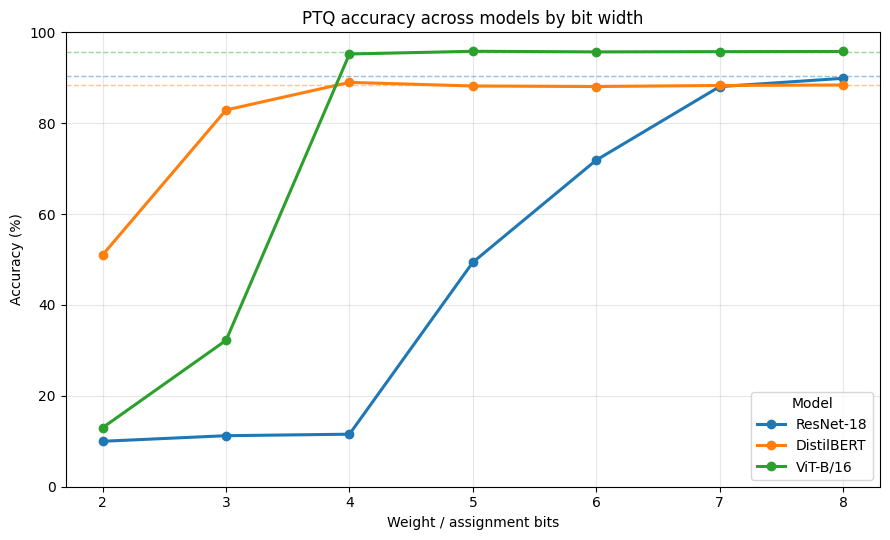

Saved PTQ comparison: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/consolidated_full_model_bit_sweeps/ptq_accuracy_all_models_2_to_8_bit.png


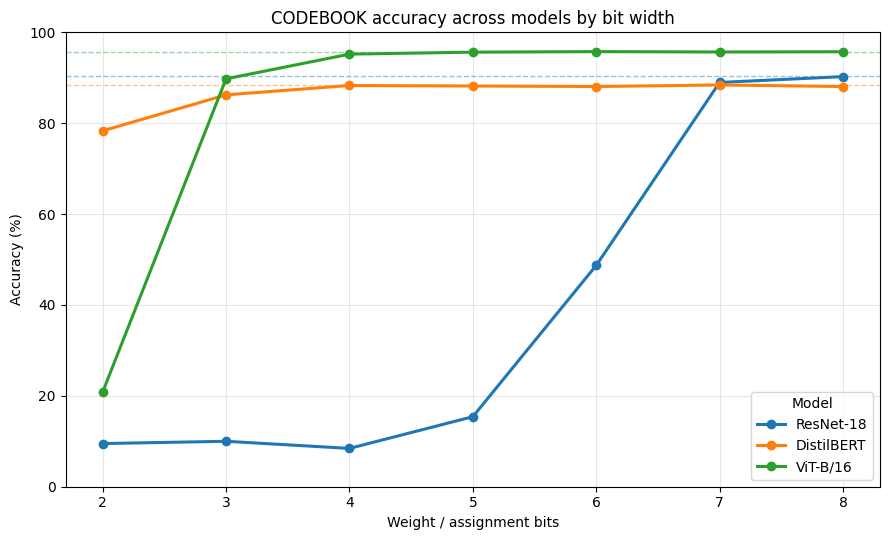

Saved CODEBOOK comparison: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/consolidated_full_model_bit_sweeps/codebook_accuracy_all_models_2_to_8_bit.png


In [8]:
model_colors = {
    'ResNet-18': '#1f77b4',
    'DistilBERT': '#ff7f0e',
    'ViT-B/16': '#2ca02c',
}

def plot_accuracy_across_models(method: str, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for model_name in models:
        rows = all_sweeps[
            all_sweeps.model.eq(model_name) & all_sweeps.method.eq(method)
        ].sort_values('num_bits')
        assert rows.num_bits.tolist() == list(BITS)
        color = model_colors[model_name]
        ax.plot(
            rows.num_bits, rows.accuracy_percent, marker='o', linewidth=2.2,
            markersize=6, color=color, label=model_name,
        )
        ax.axhline(
            fp32_accuracy_by_model[model_name], color=color, linestyle='--',
            linewidth=1, alpha=0.45,
        )
    ax.set_title(f'{method.upper()} accuracy across models by bit width')
    ax.set_xlabel('Weight / assignment bits')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(BITS)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Model', loc='lower right')
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved {method.upper()} comparison: {output_path}')

plot_accuracy_across_models('ptq', PTQ_ACCURACY_COMPARISON_PATH)
plot_accuracy_across_models('codebook', CODEBOOK_ACCURACY_COMPARISON_PATH)


## 8. Saved report artifacts


In [9]:
manifest = {
    "fp32_table": str(OUTPUT_DIR / "fp32_full_model_accuracy.csv"),
    "w8_table": str(W8_TABLE_PATH),
    "combined_saved_sweep_table": str(COMBINED_SWEEP_PATH),
    "combined_figure": str(FIGURE_PATH),
    "ptq_accuracy_comparison_figure": str(PTQ_ACCURACY_COMPARISON_PATH),
    "codebook_accuracy_comparison_figure": str(CODEBOOK_ACCURACY_COMPARISON_PATH),
    "source_artifacts": [
        str(path.relative_to(PROJECT_ROOT))
        for path in [
            RESNET_SWEEP_PATH, DISTILBERT_SWEEP_PATH,
            VIT_SWEEP_PATH, RESNET_ACCURACY_PATH, DISTILBERT_ACCURACY_PATH,
            VIT_ACCURACY_PATH, RESNET_MEMORY_PATH, DISTILBERT_MEMORY_PATH,
            VIT_MEMORY_PATH,
        ]
    ],
    "saved_bit_coverage": {f"{model}/{method}": bits for (model, method), bits in expected_coverage.items()},
    "model_execution_performed": False,
    "quantization_performed": False,
    "inference_performed": False,
}
with (OUTPUT_DIR / "results_manifest.json").open("w") as handle:
    json.dump(manifest, handle, indent=2)
display(pd.Series(manifest, name="value").to_frame())


,value
fp32_table,/Users/sahil/Group Studies/Quantization-Group-...
w8_table,/Users/sahil/Group Studies/Quantization-Group-...
combined_saved_sweep_table,/Users/sahil/Group Studies/Quantization-Group-...
combined_figure,/Users/sahil/Group Studies/Quantization-Group-...
ptq_accuracy_comparison_figure,/Users/sahil/Group Studies/Quantization-Group-...
codebook_accuracy_comparison_figure,/Users/sahil/Group Studies/Quantization-Group-...
source_artifacts,[artifacts/resnet18_full_ptq_codebook_bit_swee...
saved_bit_coverage,"{'ResNet-18/ptq': [2, 3, 4, 5, 6, 7, 8], 'ResN..."
model_execution_performed,False
quantization_performed,False
